In [1]:
from qiskit import qpy
# n=8
# p=0.3
# path = '/Users/xinpengli/Desktop/CutOpt2/Experiment/Cutqc/'+str(n)+'node_p='+str(p)+'(1)/' 
path = 'Experiment_IBM/'
with open(path+'Circuit.qpy', 'rb') as fd:
    qc = qpy.load(fd)[0]

In [3]:
from util import evaluate_circuit, calculate_fidelity,reorder_qubits
true_prob = evaluate_circuit(qc,2**25)

In [4]:
from util import store_solution, read_solution
# store_solution(cut_solution, path+'/Cutqc/cut_solution/')
cut_solution = read_solution(path+'/cut_solution/', qc)
# cut_solution = read_solution(path+'/Cutqc/cut_solution/', qc)

In [5]:
from Cutting_evaluation_Opt import  get_circuit_to_run, pre_recontruction

circuits_to_run, labels ,cutting_downstream_qubits_list, measurement_qubits_list = get_circuit_to_run(cut_solution)

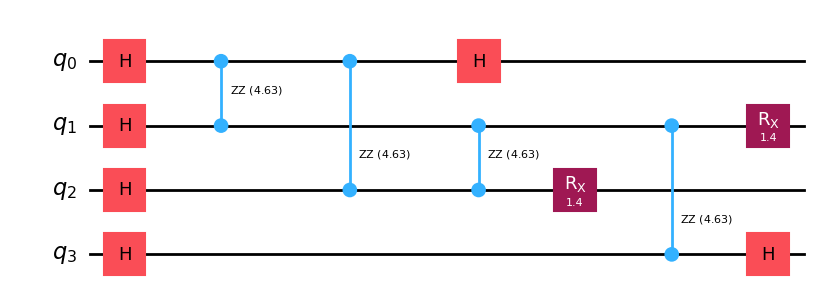

In [11]:
circuits_to_run[5].draw()

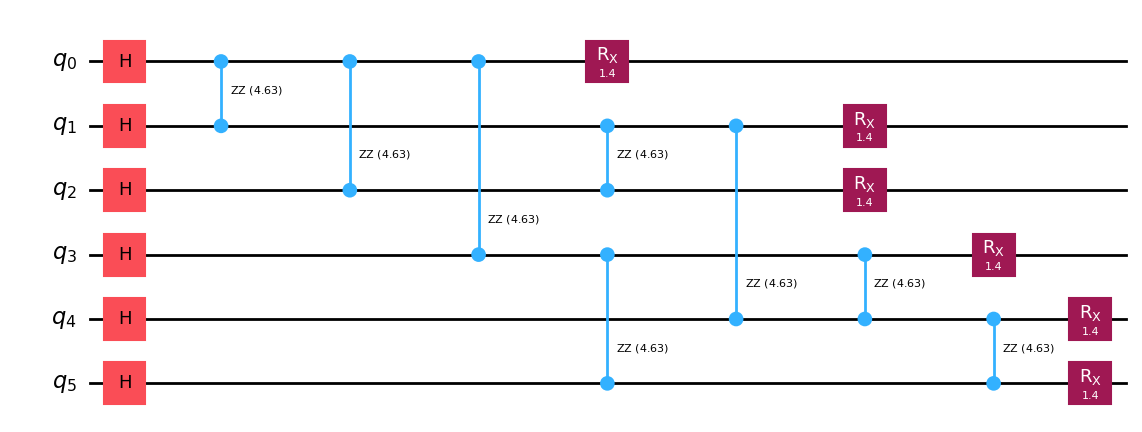

In [2]:
qc.draw()

Run on real device

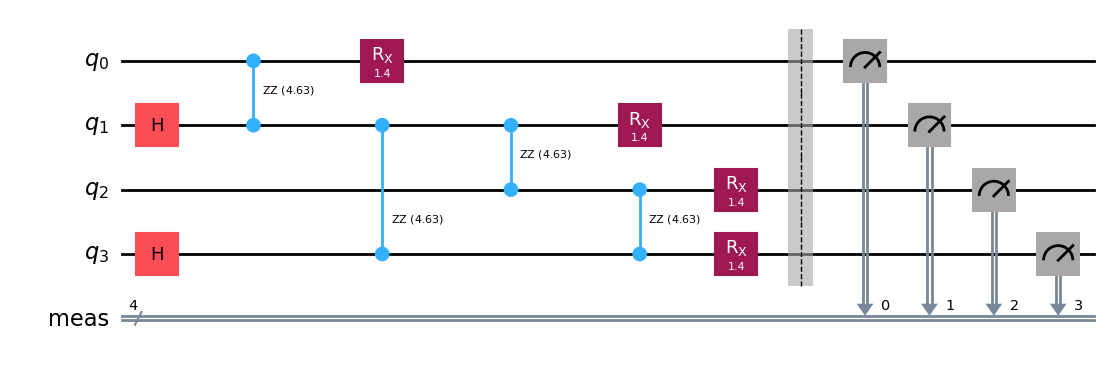

In [262]:
circuits_to_run[9].draw()

In [93]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
QiskitRuntimeService.save_account(
  token='132fa1bb2afa7ace6c14110b07225f62b4cbec429d5fcaa170602f08f8525b72460a500f423ae23f679b1b2542a52da0d80bd3ccfdfab5edebba23d84ffc7c1d',
  channel="ibm_quantum", # `channel` distinguishes between different account types
  overwrite=True
)

Orignal Circuit

In [149]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel='ibm_quantum',
    instance='ibm-q-ccf/qradle-catalyzer/qradle-catalyzer',
)

# Or save your credentials on disk.
# QiskitRuntimeService.save_account(channel='ibm_quantum', instance='ibm-q-ccf/qradle-catalyzer/qradle-catalyzer', token='<IBM Quantum API key>')

In [150]:
backend = service.backend('ibm_cleveland')

In [13]:
for c in circuits_to_run:
    c.measure_all()

In [14]:
qc.measure_all()

In [204]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)

In [205]:
with Session(backend=backend) as session:
    sampler = Sampler(mode=session)
    job = sampler.run([isa_circuit], shots = backend.max_shots)
    pub_result = job.result()
    print(f"Sampler job ID: {job.job_id()}")

Sampler job ID: cysv5zq4raf0008eamjg


In [206]:
import numpy as np

IBM_qc_prob_result = dict(pub_result[0].data.items())['meas'].array
IBM_qc_prob_result_array_list = IBM_qc_prob_result.flatten().tolist()

# Step 1: Create an array of zeros (or any initial values)
size = 2**6  # Define the size of the array (ensure it's large enough)
arr = np.zeros(size, dtype=int)

# Step 2: List of position indices
positions = IBM_qc_prob_result_array_list

# Step 3: Increment values at the specified positions
np.add.at(arr, positions, 1)

print(arr)

[3177 1912  715  933 3065 1383 1324  387  982  992 1316 1080  607 3985
 1354  770  803  524 3403 1877 2006  544 1733 1616  938  732 1080 5547
 2148  913 1009 1355 1549  705  599 1594 1567 4004  864  656 2039 2728
 2594  572 2507 1169 1546  515  558 1120 1574 4545  563  773 2131 1526
 2043  549 2368 1475  956  869 1838 1694]


In [ ]:
28, 38 ,19

In [207]:
calculate_fidelity(true_prob,arr)

0.4515829425615138

Reconstruct Circuit

In [241]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(circuits_to_run)

In [242]:
with Session(backend=backend) as session:
    sampler = Sampler(mode=session)
    job = sampler.run(isa_circuit, shots = backend.max_shots)
    pub_result = job.result()
    print(f"Sampler job ID: {job.job_id()}")

Sampler job ID: cysvjwvjj6dg008e4w50


In [243]:
import json
import numpy as np

result = []

for i, _pub_result in enumerate(pub_result):
    IBM_qc_prob_result = dict(_pub_result.data.items())['meas'].array
    IBM_qc_prob_result_array_list = IBM_qc_prob_result.flatten().tolist()

    # Step 1: Create an array of zeros (or any initial values)
    size = 2**4  # Define the size of the array (ensure it's large enough)
    arr = np.zeros(size, dtype=int)

    # Step 2: List of position indices
    positions = IBM_qc_prob_result_array_list

    # Step 3: Increment values at the specified positions
    np.add.at(arr, positions, 1)

    # Write the list to a JSON file
    with open(path+'IBM_subcircuit'+str(i)+'_prob.json', 'w') as file:
        json.dump(arr.tolist(), file)

    result.append(arr)

In [244]:
from util import evaluate_circuit
subcircuit_prob = {i:[] for i in range(len(cut_solution['subcircuits']))}
subcircuit_ecr = {i:0 for i in range(len(cut_solution['subcircuits']))}
for i, (c, l) in enumerate(zip(circuits_to_run, labels)):
    subcircuit_prob[l].append(result[i])
    subcircuit_ecr[l] += isa_circuit[i].count_ops()['ecr']

In [245]:
subcircuit_ecr[0]/len(subcircuit_prob[0]) + subcircuit_ecr[1]/len(subcircuit_prob[1])

21.430555555555557

In [220]:
from circuit_knitting.cutting.cutqc.wire_cutting_evaluation import  mutate_measurement_basis, measure_prob
from Cutting_evaluation_Opt import modify_subcircuit_instance
from multiprocessing.pool import ThreadPool
from circuit_knitting.cutting.cutqc.wire_cutting import _generate_metadata
from typing import Sequence, Any
from util import reorder_qubits, evaluate_circuit
from qiskit import QuantumCircuit
def _run_subcircuit_batch(
    subcircuit_instance: dict[tuple[tuple[str, ...], tuple[Any, ...]], int],
    subcircuit: QuantumCircuit,
    subcircuit_idx
):
    """
    Execute a circuit using qiskit runtime.

    Args:
        subcircuit_instances: Dictionary containing information about each of the
            subcircuit instances
        subcircuit: The subcircuit to execute
        service: The runtime service
        backend_name: The backends used to execute the subcircuit
        options: Options for the runtime execution of subcircuit

    Returns:
        The measurement probabilities for the subcircuit batch, as calculated from the
        runtime execution
    """
    subcircuit_instance_probs = {}
    circuits_to_run = []
    subcircuit_init_qubits_list=[]
    subcircuit_meas_qubits_list=[]
    subcircuit_meas_basis_list=[]

    # For each circuit associated with a given subcircuit
    for init_meas in subcircuit_instance:
        subcircuit_instance_idx = subcircuit_instance[init_meas]

        # Collect all of the circuits we need to evaluate, ensuring we don't have duplicates
        if subcircuit_instance_idx not in subcircuit_instance_probs:
            modified_subcircuit_instance, init_qubits, meas_qubits = modify_subcircuit_instance(
                subcircuit=subcircuit,
                init=init_meas[0],
                meas=tuple(init_meas[1]),
            )
            circuits_to_run.append(modified_subcircuit_instance)
            subcircuit_init_qubits_list.append(init_qubits)
            subcircuit_meas_qubits_list.append(meas_qubits)
            subcircuit_meas_basis_list.append(tuple(init_meas[1]))
            mutated_meas = mutate_measurement_basis(meas=tuple(init_meas[1]))
            for meas in mutated_meas:
                mutated_subcircuit_instance_idx = subcircuit_instance[
                    (init_meas[0], meas)
                ]
                # Set a placeholder in the probability dict to prevent duplicate circuits to the Sampler
                subcircuit_instance_probs[mutated_subcircuit_instance_idx] = np.array(
                    [0.0]
                )

    # Run all of our circuits in one batch
    # subcircuit_inst_probs = run_subcircuits(
    #     circuits_to_run
    # )
    # subcircuit_inst_probs = run_subcircuits(
    #     circuits_to_run
    # )
    subcircuit_inst_probs = subcircuit_prob[subcircuit_idx]

    # for i, (a,b) in enumerate(zip(subcircuit_inst_probs,subcircuit_inst_probs_2)):
    #     if calculate_fidelity(a,b)<0.988:
    #         print(i, subcircuit_meas_qubits_list[i])

    # Calculate the measured probabilities
    unique_subcircuit_check = {}
    i = 0
    for init_meas in subcircuit_instance:
        subcircuit_instance_idx = subcircuit_instance[init_meas]
        if subcircuit_instance_idx not in unique_subcircuit_check:
            subcircuit_inst_prob = subcircuit_inst_probs[i]
            i = i + 1
            mutated_meas = mutate_measurement_basis(meas=tuple(init_meas[1]))
            for meas in mutated_meas:
                measured_prob = measure_prob(
                    unmeasured_prob=subcircuit_inst_prob, meas=meas
                )
                mutated_subcircuit_instance_idx = subcircuit_instance[
                    (init_meas[0], meas)
                ]
                subcircuit_instance_probs[
                    mutated_subcircuit_instance_idx
                ] = measured_prob
                unique_subcircuit_check[mutated_subcircuit_instance_idx] = True

    return subcircuit_instance_probs

# def run_subcircuits(subcircuits):
#     return [evaluate_circuit(c, 2**(20)) for c in subcircuits]

In [227]:
import numpy as np
def run_subcircuit_instances(
    subcircuits: Sequence[QuantumCircuit],
    subcircuit_instances: dict[int, dict[tuple[tuple[str, ...], tuple[Any, ...]], int]],
) -> dict[int, dict[int, np.ndarray]]:
    """
    Execute all provided subcircuits.

    Using the backend(s) provided, this executes all the subcircuits to generate the
    resultant probability vectors.
    subcircuit_instance_probs[subcircuit_idx][subcircuit_instance_idx] = measured probability

    Args:
        subcircuits: The list of subcircuits to execute
        subcircuit_instances: Dictionary containing information about each of the
            subcircuit instances
        service: The runtime service
        backend_names: The backend(s) used to execute the subcircuits
        options: Options for the runtime execution of subcircuits

    Returns:
        The probability vectors from each of the subcircuit instances
    """
    subcircuit_instance_probs: dict[int, dict[int, np.ndarray]] = {}
    with ThreadPool() as pool:
        args = [
            [
                subcircuit_instances[subcircuit_idx],
                subcircuit,
                subcircuit_idx
            ]
            for subcircuit_idx, subcircuit in enumerate(subcircuits)
        ]
        subcircuit_instance_probs_list = pool.starmap(_run_subcircuit_batch, args)

        for i, partition_batch in enumerate(subcircuit_instance_probs_list):
            subcircuit_instance_probs[i] = partition_batch

    return subcircuit_instance_probs

In [246]:
_, _, subcircuit_instances = _generate_metadata(cut_solution)
subcircuit_instance_probs = run_subcircuit_instances(cut_solution['subcircuits'],subcircuit_instances)

In [247]:
from circuit_knitting.cutting.cutqc import (
    reconstruct_full_distribution, reconstruct_dd_full_distribution
)

# CutQC_path ='Result/QAOA/8node_1/CutQC_solution/'
# New_path ='Result/QAOA/8node_1/New_solution/'
# backend_name = 'ibmq_qasm_simulator'

reconstructed_probabilities = reconstruct_full_distribution(
    qc, subcircuit_instance_probs,cut_solution
)

In [239]:
from util import prob_normalization
prob_normalization(reconstructed_probabilities)[27]
prob_normalization(reconstructed_probabilities)[37]
prob_normalization(reconstructed_probabilities)[0]

0.02479634225

In [197]:
from util import evaluate_circuit, calculate_fidelity,reorder_qubits
from itertools import permutations

def generate_permutations(n):
    nums = list(range(n + 1))  # Create a list from 0 to n
    perms = list(permutations(nums))  # Generate all permutations
    return perms

# Example usage
n = 5
max_f = 0
max_per = None
for perm in generate_permutations(n):
    reorder_arr = reorder_qubits(reconstructed_probabilities,list(perm))
    f = calculate_fidelity(true_prob, abs(reorder_arr))
    if f > max_f:
        max_f = f
        max_per = perm
print(max_f, max_per)

0.47667139253058133 (1, 4, 5, 3, 0, 2)


In [240]:
reorder_arr = reorder_qubits(reconstructed_probabilities,[5,4,3,2,1,0])
calculate_fidelity(true_prob, abs(reorder_arr))

0.45203247388016493

In [248]:
calculate_fidelity(true_prob, abs(reconstructed_probabilities))

0.5118918927451226

In [259]:
abs(reconstructed_probabilities)

array([1.88987010e+08, 4.00176970e+07, 8.29604280e+07, 1.21735440e+07,
       3.56491420e+07, 2.58379490e+08, 3.97002141e+08, 2.31981954e+08,
       2.43289136e+08, 2.20034534e+08, 7.01536275e+07, 1.43155238e+08,
       5.13182596e+08, 4.63779835e+07, 1.36113760e+07, 5.12032436e+08,
       1.15316055e+08, 4.12366550e+06, 2.53439260e+08, 7.00625420e+07,
       1.21301804e+08, 2.88450582e+08, 4.93039530e+07, 6.56057505e+07,
       5.58190695e+07, 1.00719083e+08, 1.36540102e+08, 4.12650952e+08,
       5.12912333e+08, 4.93078560e+07, 5.21216470e+07, 1.29397001e+08,
       6.39876380e+07, 9.50744595e+07, 1.70470336e+08, 3.91403268e+08,
       4.68646008e+08, 1.22553660e+08, 7.22338600e+06, 1.34971458e+08,
       1.12671012e+08, 3.67489910e+07, 1.80530278e+08, 1.08356110e+08,
       1.46324244e+08, 3.25300550e+08, 1.52448766e+08, 7.89049205e+07,
       2.18231411e+08, 1.81873642e+08, 1.21523125e+08, 1.72494462e+08,
       4.89484170e+08, 6.02655515e+07, 4.34154030e+07, 4.81788284e+08,
      

In [258]:
true_prob

array([5.19102514e-02, 1.13570690e-03, 1.15090609e-03, 1.88946724e-05,
       2.27689743e-05, 9.50217247e-04, 9.53316689e-04, 5.21717668e-02,
       1.13809109e-03, 5.92212379e-02, 2.92330980e-04, 1.43757463e-03,
       1.00621581e-03, 5.96076250e-04, 5.96826375e-02, 9.58681107e-04,
       1.14807487e-03, 2.96503305e-04, 5.91451228e-02, 1.44043565e-03,
       1.00728869e-03, 5.98589182e-02, 5.95033169e-04, 9.61631536e-04,
       1.98781490e-05, 1.42917037e-03, 1.42639875e-03, 6.87235594e-02,
       6.91081882e-02, 1.00034475e-03, 1.01339817e-03, 2.53617764e-05,
       2.40802765e-05, 1.02201104e-03, 1.01491809e-03, 6.91889226e-02,
       6.87796175e-02, 1.42675638e-03, 1.43635273e-03, 1.90138817e-05,
       9.57220793e-04, 5.93036413e-04, 5.98137379e-02, 1.01047754e-03,
       1.43009424e-03, 5.92215955e-02, 2.98798084e-04, 1.13323331e-03,
       9.62942839e-04, 5.97196519e-02, 5.98728657e-04, 1.01307034e-03,
       1.43995881e-03, 2.97307968e-04, 5.91990650e-02, 1.13612413e-03,
      

In [143]:
import json

# Write the list to a JSON file
with open(path+'IBM_qc_prob_2.json', 'w') as file:
    json.dump(arr.tolist(), file)
# import pickle
# with open(path+'prob.pkl', 'wb') as file:
#     pickle.dump(true_prob, file)

In [142]:
arr

array([ 618, 1249, 1325, 1848, 1505, 1501, 2397,  807,  647, 1754, 2722,
       1160, 1120,  577,  730, 2619, 2432, 2362, 2331, 1550, 1125, 1201,
       1160, 1201, 1791, 4966, 1379,  752, 1809, 1221,  929, 1268, 2251,
       5642, 1045,  662, 1244, 1337,  954,  802, 2191,  986, 2413, 1663,
       1794,  974, 1112,  809,  727, 1166, 2346, 2243, 1185,  767, 1312,
       3225,  655,  851, 1835, 1474, 1402, 1263, 2916,  698])

In [80]:
calculate_fidelity(true_prob, abs(reconstructed_probabilities))

0.9743997121420275

In [68]:
2**30

1073741824